# Machine Learning: Linear Regression with Titanic Data

Let's build Simple Linear Regression from the beginning using the Titanic dataset (kashti), step by step.

Goal: Predict a passenger's Fare based on their Age.

Here,

X = Age → independent variable\
y = Fare → dependent variable

# 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. Load the Titanic dataset

In [3]:
# if you need to load your own data
# df = pd.read_csv("titanic.csv")

In [4]:
df = sns.load_dataset('titanic')

In [12]:
df.head()
df.info()
df[['age', 'fare']].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,age,fare
count,891.000000,891.000000
mean,29.361582,32.204208
std,13.019697,49.693429
min,0.420000,0.000000
25%,22.000000,7.910400
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


## Handle missing values

In [13]:
df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())

In [17]:
df[['age', 'fare']].isnull().sum()

age     0
fare    0
dtype: int64

## Check outliers using boxplots

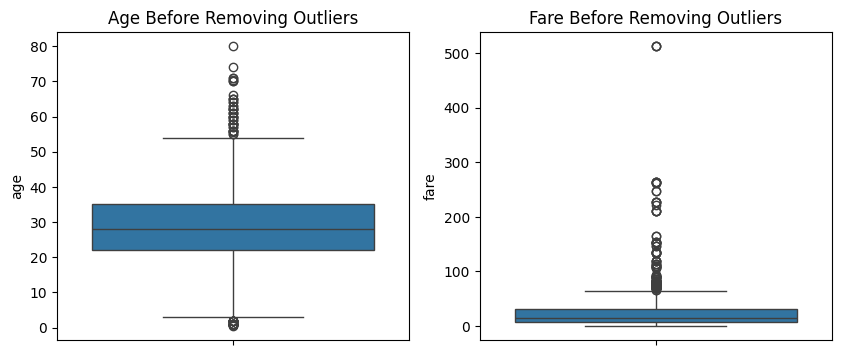

In [14]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['age'])
plt.title('Age Before Removing Outliers')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['fare'])
plt.title('Fare Before Removing Outliers')

plt.show()

## Remove outliers using IQR

In [15]:
Q1_age = df['age'].quantile(0.25)
Q3_age = df['age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

Q1_fare = df['fare'].quantile(0.25)
Q3_fare = df['fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare

df = df[
    (df['age'] >= Q1_age - 1.5 * IQR_age) &
    (df['age'] <= Q3_age + 1.5 * IQR_age) &
    (df['fare'] >= Q1_fare - 1.5 * IQR_fare) &
    (df['fare'] <= Q3_fare + 1.5 * IQR_fare)
]

## Check outliers again

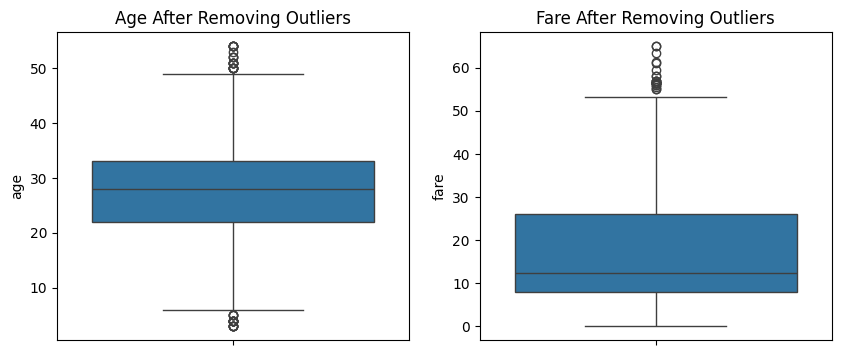

In [16]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['age'])
plt.title('Age After Removing Outliers')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['fare'])
plt.title('Fare After Removing Outliers')

plt.show()

# 3. Select variables

1. X = Independent variable
2. y = Dependent variable

In [5]:
X = df[['age']]
y = df['fare']

# 4. Visualize the relationship
Before building the model, check whether Age and Fare have a roughly linear relationship.

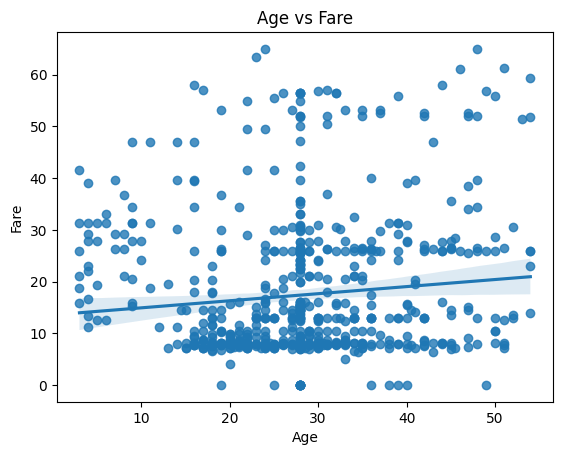

In [18]:
sns.regplot(data=df, x='age', y='fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare')
plt.show()

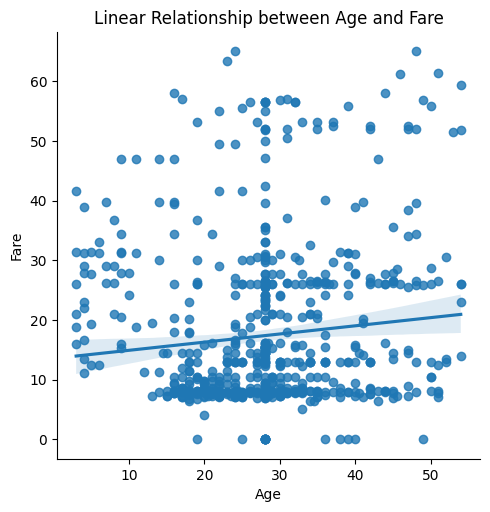

In [24]:
sns.lmplot(data=df, x='age', y='fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Linear Relationship between Age and Fare')
plt.show()

In [26]:
df_linear = df[["age", "fare"]]
df_linear

,age,fare
0,22.0,7.2500
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
5,28.0,8.4583
...,...,...
886,27.0,13.0000
887,19.0,30.0000
888,28.0,23.4500
889,26.0,30.0000


In [27]:
df_linear.age.fillna(value = df_linear['age'].mean(), inplace=True)

C:\Users\Hp\AppData\Local\Temp\ipykernel_19904\1602816702.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_linear.age.fillna(value = df_linear['age'].mean(), inplace=True)
C:\Users\Hp\AppData\Local\Temp\ipykernel_19904\1602816702.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_linear.age.fillna(value = df_linear['age'].mean(), inp

In [28]:
df_linear.isnull().sum()

age     0
fare    0
dtype: int64

# 5. Train-test split

In [31]:
X = df_linear[['age']]
y = df_linear['fare']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.8)

# 6. Create and train model

In [33]:

# call the model
model = LinearRegression()
# train the model
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
model.predict([[25]])

c:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([16.96637914])

## Check regression equation

In [36]:
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 11.946460157774965
Slope: 0.1868999687916521


## Evaluation

In [39]:
# model evaluation with matrics if predictions sre true or not
# r2
# mean squared error
# MEA
# RMSE

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.8)

# model
model = LinearRegression()

# train
model.fit(X_train, y_train)

# prediction
y_pred=model.predict(X_test)

## Evaluation

In [40]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 9.55309162890722
MSE: 133.79820891500802
RMSE: 11.567117571590945
R²: -0.0008389456837110121


In [42]:
## Actual vs predicted
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
618,39.0000,15.150111
814,8.0500,18.041906
17,13.0000,17.769096
441,9.5000,16.896101
733,13.0000,17.223474
754,65.0000,19.951582
417,13.0000,16.677852
199,13.0000,17.332598
640,7.8542,16.896101
236,26.0000,19.515085


## Residual plot

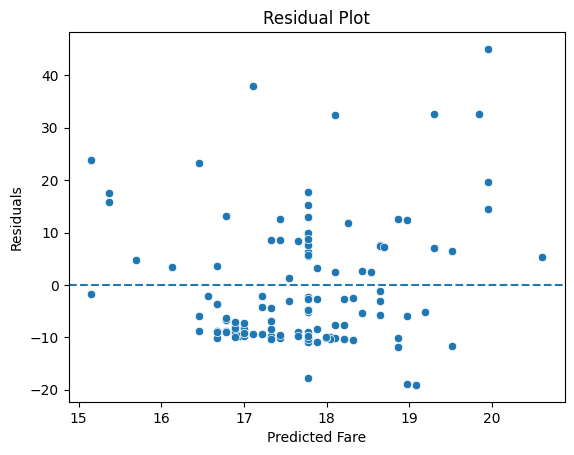

In [43]:
residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, linestyle='--')

plt.xlabel('Predicted Fare')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

In [44]:
model.score(X_test,y_test)

-0.0008389456837110121

In [45]:
score = model.score(X_test, y_test)
print("R² Score:", score)

R² Score: -0.0008389456837110121


### In Linear Regression, model.score() returns the R² score (coefficient of determination).

Role

It measures how well the regression model explains the variation in the dependent variable (y) using the independent variable (X).

If the result is: R² Score: 0.35, It means the model explains approximately 35% of the variation in Fare based on Age.

Importance
R² = 1.00 → Perfect prediction\
R² = 0.80 → Model explains 80% of variation\
R² = 0.50 → Model explains 50% of variation\
R² = 0.10 → Weak explanatory power\
R² = 0 → Model explains no more variation than predicting the mean\
R² < 0 → Model performs worse than simply predicting the mean




In [ ]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, y_pred)

print("MAE :", MAE) 
print("MSE :", MSE)
print("RMSE:", RMSE)
print("R²  :", R2) # highr r2, better results

MAE : 9.55309162890722
MSE : 133.79820891500802
RMSE: 11.567117571590945
R²  : -0.0008389456837110121


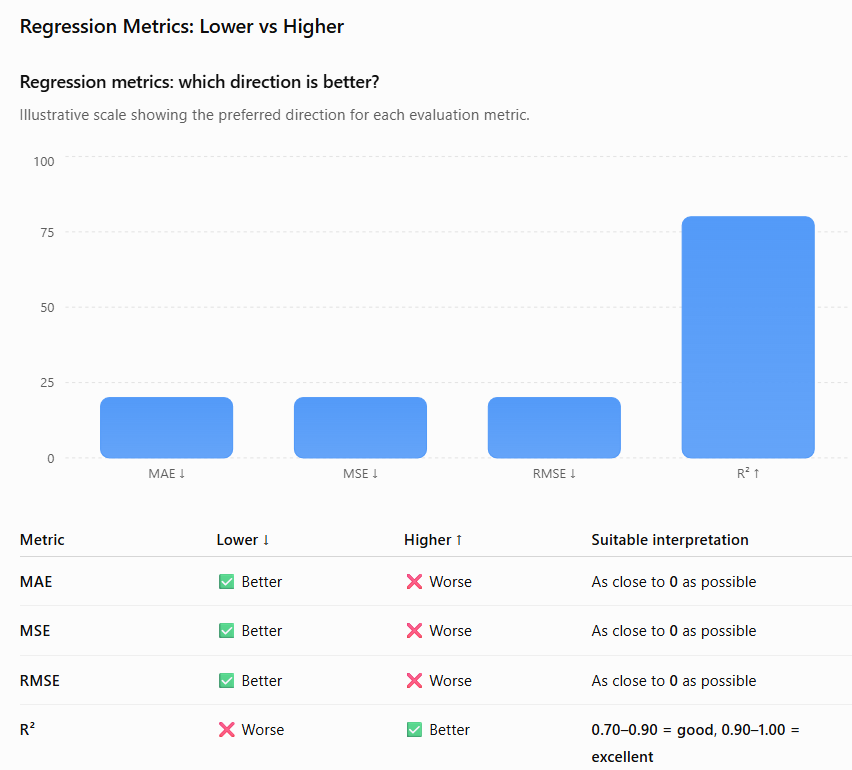

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

In [6]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
df.isnull().sum() / len(df) *100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64